
## <center><strong style="font-size: 32px; color: #28B463;">DỰ ĐOÁN Ý ĐỊNH MUA HÀNG TRỰC TUYẾN THÔNG QUA TÍCH HỢP KỸ THUẬT PHÂN CỤM K-MEANS VÀ CÂY QUYẾT ĐỊNH</strong></center>
### **Thông tin đề tài**
- **Mục tiêu chính**:  
  - Phân đoạn khách hàng dựa trên hành vi truy cập website bằng thuật toán **K-Means**  
  - Xây dựng mô hình dự đoán hành vi mua hàng (**Revenue = True/False**) bằng **Cây quyết định** trên từng cụm  
  - Kết hợp hai kỹ thuật để nâng cao độ chính xác và khả năng giải thích của mô hình  

- **Dữ liệu sử dụng**: Online Shoppers Purchasing Intention Dataset  
- **Biến mục tiêu**: `Revenue` (True: có mua hàng, False: không mua hàng)

### **Quy trình chính**
1. Tiền xử lý dữ liệu  
2. Biến đổi dữ liệu
2. Phân cụm bằng **K-Means**  
3. Huấn luyện **Cây quyết định** trên từng cụm  
4. Đánh giá và kết luận  

> **Kết quả mong đợi**: Tăng độ chính xác dự đoán, cải thiện khả năng giải thích và hỗ trợ chiến lược marketing cá nhân hóa theo từng nhóm khách hàng.


# ***Bước 1: Tiền xử lý dữ liệu***
**Mục tiêu:** Làm sạch dữ liệu (xử lý giá trị null, loại bỏ dữ liệu trùng lặp và các cột không cần thiết) để chuẩn bị cho bước biến đổi dữ liệu.


### 1.1 Import dữ liệu và kiểm tra sơ bộ


In [1]:
from google.colab import drive
import pandas as pd
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Đọc file dataset
df = pd.read_csv("/content/drive/MyDrive/02-KPDL/Data/du_lieu.csv")


### 1.2 Kiểm tra cấu trúc và dữ liệu


In [3]:
# Hiển thị toàn bộ dataframe
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0.0,0.0,4,1135.000,0.026667,0.046667,0.0,0.8,May,2,2,2,4,Returning _Visitor,False,False
1,2,107.4,2.0,96.7,32,833.325,0.024510,0.035882,0.0,0.0,July,3,2,4,1,Returning_Visitor,False,True
2,9,0.0,0.0,0.0,20,0.000,0.025926,0.040923,0.0,0.0,Nov,2,2,7,1,Returning_Visitor,False,False
3,2,86.0,0.0,0.0,18,0.000,0.000000,0.005556,0.0,0.0,May,3,2,6,2,New _ Visitor,False,False
4,10,150.0,0.0,0.0,24,0.000,0.000000,0.007993,0.0,0.0,May,1,1,3,2,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7107,4,91.0,3.0,135.5,69,0.000,0.004762,0.009852,0.0,0.0,May,1,1,1,4,Returning_Visitor,False,False
7108,0,0.0,0.0,0.0,5,91.000,0.000000,0.060000,0.0,0.6,May,1,1,1,3,Returning_Visitor,False,False
7109,4,40.5,0.0,0.0,32,0.000,0.000000,0.028788,0.0,0.0,May,3,2,6,3,Returning_Visitor,False,False
7110,0,0.0,4.0,37.0,69,0.000,0.007123,0.022355,0.0,0.0,December,3,2,3,2,Returning_Visitor,False,False


In [4]:
print(" Thông tin chung về DataFrame (bao gồm kiểu dữ liệu và giá trị không rỗng)")
df.info()

 Thông tin chung về DataFrame (bao gồm kiểu dữ liệu và giá trị không rỗng)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           7112 non-null   int64  
 1   Administrative_Duration  7112 non-null   float64
 2   Informational            7107 non-null   float64
 3   Informational_Duration   7109 non-null   float64
 4   ProductRelated           7112 non-null   int64  
 5   ProductRelated_Duration  7112 non-null   float64
 6   BounceRates              7112 non-null   float64
 7   ExitRates                7112 non-null   float64
 8   PageValues               7112 non-null   float64
 9   SpecialDay               7112 non-null   float64
 10  Month                    7112 non-null   object 
 11  OperatingSystems         7112 non-null   int64  
 12  Browser                  7112 non-null   int64  
 13  Reg

In [5]:
print("Thống kê mô tả cho các cột số")
print(df.describe())

Thống kê mô tả cho các cột số
       Administrative  Administrative_Duration  Informational  \
count     7112.000000              7112.000000    7107.000000   
mean         2.500703                56.512025       0.562263   
std          3.434666               147.133343       1.327108   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 0.000000       0.000000   
75%          4.000000                57.500000       0.000000   
max         27.000000              3398.750000      16.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count             7109.000000     7112.000000              7112.000000   
mean                31.116858       34.712739               303.435142   
std                129.169141       47.076088               803.187170   
min                  0.000000        0.000000                 0.000000   
25%           

### 1.3 Xử lý dữ liệu trùng lặp


In [6]:
print("Số lượng hàng trùng lặp")
print(df.duplicated().sum())

Số lượng hàng trùng lặp
204


In [7]:
# Xóa các hàng trùng lặp, giữ lại hàng đầu tiên
df = df.drop_duplicates(keep='first')

# Kiểm tra lại số hàng còn lại
print("Số hàng sau khi loại trùng:", len(df))


Số hàng sau khi loại trùng: 6908


### 1.4 Kiểm tra và xử lý giá trị thiếu


In [8]:
print("Số lượng giá trị thiếu trong mỗi cột")
print(df.isnull().sum())

Số lượng giá trị thiếu trong mỗi cột
Administrative             0
Administrative_Duration    0
Informational              5
Informational_Duration     3
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [9]:
# Xử lý giá trị thiếu cho các cột cụ thể
cols = [
    "Informational",
    "Informational_Duration"
]
for col in cols:
    df.loc[:, col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

### 1.5 Kiểm tra dữ liệu sau khi xử lý



In [10]:
print("Kiểm tra lại số lượng giá trị thiếu trong mỗi cột")
print(df.isnull().sum())

Kiểm tra lại số lượng giá trị thiếu trong mỗi cột
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [11]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,float64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


### 1.6 Chuẩn hóa dữ liệu


In [12]:
# Chuẩn hóa dữ liệu số bị lỗi định dạng
import pandas as pd
df = df.replace(',', '.', regex=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipython-input-3458519968.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [13]:
# Kiểm tra dữ liệu không nhất quán trong cột `VisitorType`.
df["VisitorType"].unique()

array(['Returning _Visitor', 'Returning_Visitor', 'New _ Visitor',
       'New_Visitor', 'Returning_ Visitor', 'New _Visitor',
       'New_ Visitor', 'Other'], dtype=object)

In [14]:
# Xử lý dữ liệu không nhất quán trong cột 'VisitorType' để chuẩn hóa định dạng.
df['VisitorType'] = df['VisitorType'].str.strip() # Xóa khoảng trắng thừa ở đầu và cuối chuỗi
df['VisitorType'] = df['VisitorType'].str.replace(r'\s+', '_', regex=True) # Thay thế nhiều khoảng trắng bằng một dấu gạch dưới
df['VisitorType'] = df['VisitorType'].str.replace(r'_+', '_', regex=True) # Xử lý trường hợp có hai dấu gạch dưới liên tiếp

In [15]:
#Kiểm tra lại các giá trị duy nhất trong cột VisitorType.
df["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

Xử lý dữ liệu không nhất quán trong Month

In [ ]:
print("\nCác giá trị trong cột Month trước khi xử lý:")
print(df['Month'].unique())

# Mapping đầy đủ (thêm biến thể nếu cần)
month_mapping = {
    'Jan': 'January', '1': 'January',
    'Feb': 'February', '2': 'February',
    'Febuary': 'February',
    'Mar': 'March', '3': 'March',
    'Apr': 'April', '4': 'April',
    'May': 'May', '5': 'May',
    'Jun': 'June', '6': 'June',
    'Jul': 'July', '7': 'July',
    'Aug': 'August', '8': 'August',
    'Sep': 'September', '9': 'September', 'Sept': 'September',
    'Oct': 'October', '10': 'October',
    'Nov': 'November', '11': 'November',
    'Dec': 'December', '12': 'December'
}
# Chuyển hết về string + loại bỏ khoảng trắng thừa
df['Month'] = df['Month'].astype(str).str.strip()

# Thay thế
df['Month'] = df['Month'].replace(month_mapping)

# Optional: Nếu muốn đổi về Categorical để sắp xếp tháng đúng thứ tự sau này
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print("\nSau khi chuẩn hóa hoàn toàn:")
print(df['Month'].unique())
print(df['Month'].value_counts())


Các giá trị trong cột Month trước khi xử lý:
['May' 'July' 'Nov' 'Dec' 'November' 'March' '5' 'June' 'October'
 'December' 'Feb' 'Oct' 'February' 'September' 'August']

Sau khi chuẩn hóa hoàn toàn:
['May', 'July', 'November', 'December', 'March', 'June', 'October', 'February', 'September', 'August']
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' <
                          'November' < 'December']
Month
May          1812
November     1802
March        1056
December      932
October       326
September     266
August        252
July          228
June          140
February       94
April           0
January         0
Name: count, dtype: int64


### 1.7 Xuất file sau khi tiền xử lý


In [ ]:
df.to_csv('/content/drive/MyDrive/02-KPDL/Data/tienxuly.csv', index=False)
print("Dữ liệu đã được xuất thành công ra file tienxuly.csv")

Dữ liệu đã được xuất thành công ra file tienxuly.csv



# ***Bước 2: Biến đổi & Chuẩn hóa dữ liệu***
**Mục tiêu:** Chuẩn bị dữ liệu sạch, đồng nhất và phù hợp để áp dụng thuật toán **K-Means** (yêu cầu dữ liệu số, không có ngoại lai nghiêm trọng và các đặc trưng ở cùng thang đo).
**Dữ liệu đầu vào:** File CSV đã làm sạch(`tienxuly.csv`).

**Kết quả:** Xuất file CSV với tên (`bddl.csv`).

### 2.1 Import dữ liệu sau tiền xử lý

In [ ]:
file_path = '/content/drive/MyDrive/02-KPDL/Data/tienxuly.csv'
df = pd.read_csv(file_path)
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0.0,0.0,4,1135.000,0.026667,0.046667,0.0,0.8,May,2,2,2,4,Returning_Visitor,False,False
1,2,107.4,2.0,96.7,32,833.325,0.024510,0.035882,0.0,0.0,July,3,2,4,1,Returning_Visitor,False,True
2,9,0.0,0.0,0.0,20,0.000,0.025926,0.040923,0.0,0.0,November,2,2,7,1,Returning_Visitor,False,False
3,2,86.0,0.0,0.0,18,0.000,0.000000,0.005556,0.0,0.0,May,3,2,6,2,New_Visitor,False,False
4,10,150.0,0.0,0.0,24,0.000,0.000000,0.007993,0.0,0.0,May,1,1,3,2,Returning_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6903,4,91.0,3.0,135.5,69,0.000,0.004762,0.009852,0.0,0.0,May,1,1,1,4,Returning_Visitor,False,False
6904,0,0.0,0.0,0.0,5,91.000,0.000000,0.060000,0.0,0.6,May,1,1,1,3,Returning_Visitor,False,False
6905,4,40.5,0.0,0.0,32,0.000,0.000000,0.028788,0.0,0.0,May,3,2,6,3,Returning_Visitor,False,False
6906,0,0.0,4.0,37.0,69,0.000,0.007123,0.022355,0.0,0.0,December,3,2,3,2,Returning_Visitor,False,False


In [ ]:
print(" Thông tin chung về DataFrame (bao gồm kiểu dữ liệu và giá trị không rỗng)")
df.info()

 Thông tin chung về DataFrame (bao gồm kiểu dữ liệu và giá trị không rỗng)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6908 entries, 0 to 6907
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           6908 non-null   int64  
 1   Administrative_Duration  6908 non-null   float64
 2   Informational            6908 non-null   float64
 3   Informational_Duration   6908 non-null   float64
 4   ProductRelated           6908 non-null   int64  
 5   ProductRelated_Duration  6908 non-null   float64
 6   BounceRates              6908 non-null   float64
 7   ExitRates                6908 non-null   float64
 8   PageValues               6908 non-null   float64
 9   SpecialDay               6908 non-null   float64
 10  Month                    6908 non-null   object 
 11  OperatingSystems         6908 non-null   int64  
 12  Browser                  6908 non-null   int64  
 13  Reg

### 2.2 Chuyển đổi dữ liệu Boolean sang 0/1


In [ ]:
# Chuyển Weekend và Revenue sang 0/1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

#### 2.2.1 Mã hóa dữ liệu phân loại


In [ ]:
# Chuyển đổi Month và VisitorType sang nhị phân 0/1
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)


In [ ]:
# Chuyển toàn bộ cột kiểu bool thành 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


In [ ]:
#Kiểm tra lại data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6908 entries, 0 to 6907
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 6908 non-null   int64  
 1   Administrative_Duration        6908 non-null   float64
 2   Informational                  6908 non-null   float64
 3   Informational_Duration         6908 non-null   float64
 4   ProductRelated                 6908 non-null   int64  
 5   ProductRelated_Duration        6908 non-null   float64
 6   BounceRates                    6908 non-null   float64
 7   ExitRates                      6908 non-null   float64
 8   PageValues                     6908 non-null   float64
 9   SpecialDay                     6908 non-null   float64
 10  OperatingSystems               6908 non-null   int64  
 11  Browser                        6908 non-null   int64  
 12  Region                         6908 non-null   i

### 2.3 Scale dữ liệu cho K-Means

In [ ]:

from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Phân loại các cột
categorical_cols = [
    'Weekend', 'Revenue', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
    'SpecialDay', # Mặc dù là số thực, nhưng có tính chất phân loại/thứ tự
    'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
    'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor'
]

# -- Các cột liên tục (cần scale)
# -- Các cột không phải là categorical_cols
continuous_cols = [col for col in df.columns if col not in categorical_cols]

# 2. Tạo bản sao của DataFrame để xử lý
df_scaled = df.copy()

# --- Thêm bước tiền xử lý để xử lý dấu phẩy làm dấu thập phân
for col in continuous_cols:
    if df_scaled[col].dtype == 'object':
        df_scaled[col] = df_scaled[col].astype(str).str.replace(',', '.', regex=False)
        df_scaled[col] = pd.to_numeric(df_scaled[col], errors='coerce')
# 3. Khởi tạo StandardScaler
scaler = StandardScaler()

# 4. Áp dụng Standard Scaling chỉ trên các cột liên tục
# Fit (học các giá trị trung bình và độ lệch chuẩn) và Transform (biến đổi)
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])

# 5. Hiển thị dữ liệu đã được scale
print("\n--- Dữ liệu đã được scale (5 hàng đầu) ---")
print(df_scaled.head())

# 6. Kiểm tra các giá trị của một cột đã scale
print("\n--- Thống kê mô tả của cột 'ProductRelated_Duration' sau khi scale ---")
print(df_scaled['ProductRelated_Duration'].describe())


--- Dữ liệu đã được scale (5 hàng đầu) ---
   Administrative  Administrative_Duration  Informational  \
0       -0.727611                -0.384878      -0.422277   
1       -0.147337                 0.343533       1.085653   
2        1.883625                -0.384878      -0.422277   
3       -0.147337                 0.198393      -0.422277   
4        2.173762                 0.632455      -0.422277   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.240743       -0.650781                 1.030341   
1                0.515309       -0.058077                 0.656111   
2               -0.240743       -0.312093                -0.377633   
3               -0.240743       -0.354429                -0.377633   
4               -0.240743       -0.227421                -0.377633   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_February  \
0     0.207019   0.196889   -0.085828         0.8  ...       -0.117453   
1     0.155811  -0.0

### 2.4 Xử lý dữ liệu ngoại lai (IQR Capping)
**Lưu ý:** Chỉ áp dụng capping cho các cột liên tục có phân bố lệch mạnh và dễ bị ảnh hưởng bởi ngoại lai.
 - Không áp dụng IQR cho Informational và Informational_Duration nếu chúng có quá nhiều giá trị 0 (zero-inflated), tránh làm mất thông tin.

In [ ]:
import numpy as np
import pandas as pd
# 2. Xác định các cột liên tục cần xử lý ngoại lai
continuous_cols = [
    'Administrative', 'Administrative_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates'
]

# 3. Tạo một bản sao để xử lý
df_processed = df.copy()
for col in continuous_cols:
    if df_processed[col].dtype == 'object': # Chỉ xử lý nếu cột có kiểu dữ liệu là object (chuỗi)
        df_processed[col] = df_processed[col].astype(str).str.replace(',', '.', regex=False)
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
print("--- Thống kê trước khi xử lý (ví dụ cột ProductRelated_Duration) ---")
print(df_processed['ProductRelated_Duration'].describe())

# 4. Hàm xử lý ngoại lai bằng phương pháp Capping (IQR)
def cap_outliers_iqr(df, col):
    """Áp dụng Capping cho các giá trị ngoại lai của một cột."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Thiết lập giới hạn
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Áp dụng capping
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

# 5. Áp dụng hàm xử lý ngoại lai cho tất cả các cột liên tục
for col in continuous_cols:
    df_processed = cap_outliers_iqr(df_processed, col)

# 6. Hiển thị kết quả sau khi xử lý
print("\n--- Thống kê sau khi xử lý (ví dụ cột ProductRelated_Duration) ---")
print(df_processed['ProductRelated_Duration'].describe())

print("\n DataFrame sau khi xử lý ngoại lai đã sẵn sàng để scale và clustering.")

--- Thống kê trước khi xử lý (ví dụ cột ProductRelated_Duration) ---
count    6908.000000
mean      304.418712
std       806.181031
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max      4995.000000
Name: ProductRelated_Duration, dtype: float64

--- Thống kê sau khi xử lý (ví dụ cột ProductRelated_Duration) ---
count    6908.000000
mean       64.028896
std       101.398039
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max       255.000000
Name: ProductRelated_Duration, dtype: float64

 DataFrame sau khi xử lý ngoại lai đã sẵn sàng để scale và clustering.


In [ ]:
df.Informational.describe()

,Informational
count,6908.000000
mean,0.560075
std,1.326418
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,16.000000


### 2.5 Chuẩn hóa dữ liệu cho K-means (Standard Scaling)
K-Means nhạy cảm với thang đo, cần chuẩn hóa các đặc trưng số về cùng phân bố (mean ≈ 0, std ≈ 1).


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Các cột liên tục đã được xác định ở các bước trước.
# Đảm bảo continuous_cols khớp với các cột đã dùng để xử lý ngoại lai.
continuous_cols = [
    'Administrative', 'Administrative_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates',
    'Informational', 'Informational_Duration', 'PageValues', 'SpecialDay'
]

# df_processed đã được tạo và xử lý ngoại lai trong các ô trước
# Chúng ta sẽ sử dụng df_processed này để chuẩn hóa.

# --- Bắt đầu phần Chuẩn hóa ---
df_scaled = df_processed.copy() # Sử dụng df_processed đã xử lý ngoại lai

# 2. Khởi tạo StandardScaler
scaler = StandardScaler()

# 3. Áp dụng Standard Scaling chỉ trên các cột liên tục
# Fit và Transform trên tập con là các cột liên tục
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])

# 4. Hiển thị 5 hàng đầu của dữ liệu đã được chuẩn hóa
print("--- Dữ liệu sau khi xử lý ngoại lai và Chuẩn hóa (Standardization) ---")
print(df_scaled.head())

# 5. Kiểm tra kết quả chuẩn hóa (Trung bình ~ 0, Độ lệch chuẩn ~ 1)
print("\n--- Kiểm tra thống kê của các cột sau khi chuẩn hóa ---")
print(df_scaled[continuous_cols].describe().loc[['mean', 'std']])

--- Dữ liệu sau khi xử lý ngoại lai và Chuẩn hóa (Standardization) ---
   Administrative  Administrative_Duration  Informational  \
0       -0.789146                -0.658910      -0.422277   
1       -0.124258                 1.424801       1.085653   
2        2.202853                -0.658910      -0.422277   
3       -0.124258                 1.009611      -0.422277   
4        2.535298                 2.130042      -0.422277   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.240743       -0.935949                 1.883517   
1                0.515309        0.103332                 1.883517   
2               -0.240743       -0.342074                -0.631507   
3               -0.240743       -0.416308                -0.631507   
4               -0.240743       -0.193605                -0.631507   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_February  \
0     1.421438   0.586512   -0.085828    3.810933  ...             

###2.6. Xuất file sau biến đổi dữ liệu

In [ ]:
from google.colab import drive
import pandas as pd
# 1. Mount Google Drive
drive.mount('/content/drive')
# 2. Đọc dữ liệu
file_path = "/content/drive/MyDrive/02-KPDL/Data/tienxuly.csv"
df = pd.read_csv(file_path)

# 3. Làm tròn 4 chữ số thập phân (chỉ cột float)
df_scaled = df_scaled.round(3)

# 4. Xem thử
df_scaled.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_February,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.789,-0.659,-0.422,-0.241,-0.936,1.884,1.421,0.587,-0.086,3.811,...,0,0,0,0,1,0,0,0,0,1
1,-0.124,1.425,1.086,0.515,0.103,1.884,1.248,0.161,-0.086,-0.302,...,0,1,0,0,0,0,0,0,0,1
2,2.203,-0.659,-0.422,-0.241,-0.342,-0.632,1.362,0.360,-0.086,-0.302,...,0,0,0,0,0,1,0,0,0,1
3,-0.124,1.010,-0.422,-0.241,-0.416,-0.632,-0.726,-1.037,-0.086,-0.302,...,0,0,0,0,1,0,0,0,0,0
4,2.535,2.130,-0.422,-0.241,-0.194,-0.632,-0.726,-0.941,-0.086,-0.302,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
df_scaled.to_csv('/content/drive/MyDrive/02-KPDL/Data/bddl.csv', index=False)
print("Dữ liệu đã được xuất thành công ra file")

Dữ liệu đã được xuất thành công ra file


# ***Bước 3: Phân cụm khách hàng bằng Elbow Method và K-Means***

**Mục đích:** Áp dụng thuật toán K-Means để phân cụm dữ liệu khách hàng trực tuyến thành 3 nhóm (Loyal, Low, Medium) dựa trên hành vi truy cập, sử dụng Elbow Method để xác định số cụm tối ưu.

**Dữ liệu đầu vào:** File CSV đã chuẩn hóa (`bddl.csv`).

**Kết quả:** Xuất file CSV với nhãn cụm (`kmeans.csv`) để sử dụng cho báo cáo hoặc phân tích tiếp theo.

### 3.1. Khai báo thư viện và dữ liệu chuẩn hóa

In [ ]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
# Đọc file đã chuẩn hóa
data = "/content/drive/MyDrive/02-KPDL/Data/bddl.csv"
#data = "/content/drive/MyDrive/dataKP/bddl.csv"
df_trans = pd.read_csv(data)
pd.set_option('display.max_columns', None)
df_trans.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Administrative,6908.0,0.000055,1.000014,-0.789,-0.789,-0.4570,0.541,2.535
Administrative_Duration,6908.0,-0.000056,1.000094,-0.659,-0.659,-0.6590,0.457,2.130
Informational,6908.0,0.000289,1.000073,-0.422,-0.422,-0.4220,-0.422,11.641
Informational_Duration,6908.0,-0.000210,1.000118,-0.241,-0.241,-0.2410,-0.241,16.923
ProductRelated,6908.0,0.000046,1.000113,-1.084,-0.787,-0.3420,0.437,2.275
ProductRelated_Duration,6908.0,-0.000191,1.000423,-0.632,-0.632,-0.6320,0.375,1.884
BounceRates,6908.0,-0.000087,1.000149,-0.726,-0.726,-0.5495,0.425,2.150
ExitRates,6908.0,0.000027,1.000150,-1.256,-0.731,-0.3400,0.433,2.178
PageValues,6908.0,-0.000169,1.000089,-0.086,-0.086,-0.0860,-0.086,25.832
SpecialDay,6908.0,0.000452,0.999954,-0.302,-0.302,-0.3020,-0.302,4.839


In [ ]:
# Đọc và kiểm tra dữ liệu đã chuẩn hóa (có chứa chuỗi không)
df_trans.applymap(lambda x: isinstance(x, str)).sum()

/tmp/ipython-input-766592388.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_trans.applymap(lambda x: isinstance(x, str)).sum()


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


###3.2. Xác định số cụm tối ưu bằng Elbow Method

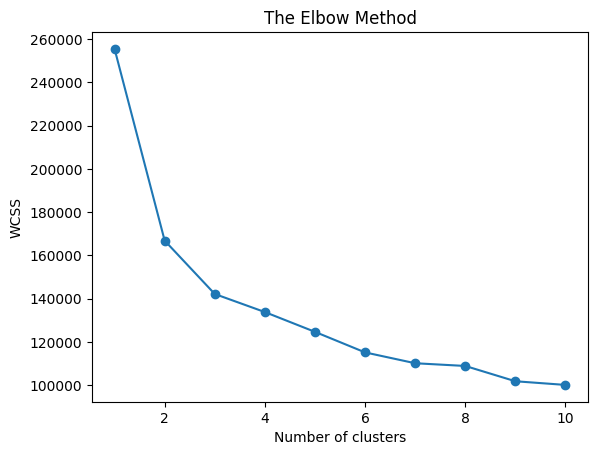

In [ ]:
# Áp dụng Elbow Method để tìm số cụm tối ưu
X = df_trans.values
wcss = [] #Within Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

###3.3. Huấn luyện mô hình K-means với số cụm K = 3

In [ ]:
# Chạy kmeans với K = 3
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

df_trans['cluster'] = kmeans.fit_predict(X)


In [ ]:
# Khởi tạo và chạy K-Means với k=3
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
# Chạy kmeans với K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_trans['cluster'] = kmeans.fit_predict(X)


In [ ]:
df_trans.groupby("cluster").mean().round(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_December,Month_February,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,VisitorType_Other,VisitorType_Returning_Visitor
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.031,0.019,-0.056,-0.037,-0.059,-0.012,-0.089,-0.079,-0.007,-0.042,2.082,2.400,6.970,2.534,0.231,0.275,0.136,0.013,0.040,0.022,0.163,0.271,0.222,0.047,0.044,0.002,0.808
1,0.021,-0.003,0.028,0.020,0.028,0.003,-0.027,-0.019,0.008,0.018,2.066,2.294,1.986,2.437,0.228,0.275,0.130,0.017,0.034,0.020,0.152,0.274,0.241,0.048,0.043,0.001,0.856
2,-0.046,-0.011,-0.045,-0.037,-0.043,0.003,0.211,0.165,-0.025,-0.019,2.410,2.635,3.168,12.088,0.257,0.282,0.153,0.000,0.023,0.019,0.143,0.205,0.383,0.044,0.016,0.033,0.836


In [ ]:
df_trans["cluster"].value_counts()

,count
cluster,
1,4467
0,1308
2,1133


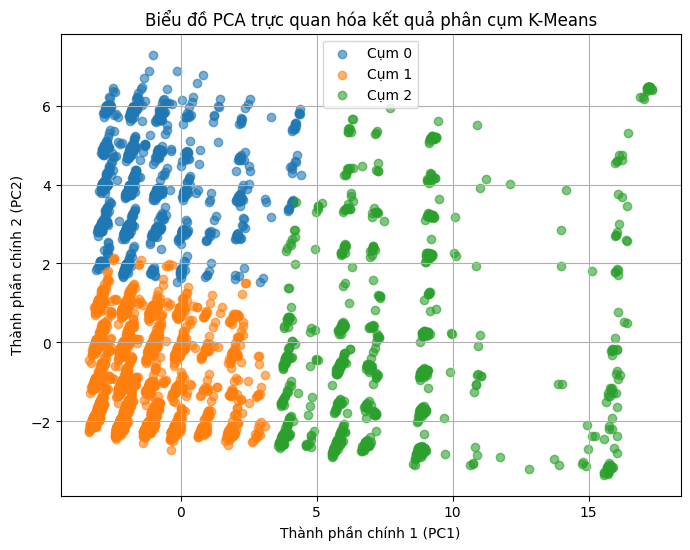

In [ ]:
X = df_trans.drop(columns=["cluster"])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = df_trans["cluster"]
plt.figure(figsize=(8, 6))

for c in sorted(df_pca["cluster"].unique()):
    plt.scatter(
        df_pca[df_pca["cluster"] == c]["PC1"],
        df_pca[df_pca["cluster"] == c]["PC2"],
        label=f"Cụm {c}",
        alpha=0.6
    )

plt.xlabel("Thành phần chính 1 (PC1)")
plt.ylabel("Thành phần chính 2 (PC2)")
plt.title("Biểu đồ PCA trực quan hóa kết quả phân cụm K-Means")
plt.legend()
plt.grid(True)
plt.show()

###3.4. Phân tích đặc điểm từng cụm


**1. Cluster 0 – Medium** (Nhóm trung bình – hành vi cân bằng)

Đặc điểm chính:
- Administrative = 0.011 (hơi cao hơn C1)
- ProductRelated = -0.022 (ít xem sản phẩm nhưng không thấp như C1)
- BounceRates = -0.004 (gần 0) → hành vi trung tính.
- ExitRates = -0.088 (THẤP) → không rời trang nhanh.
- VisitorType_Returning_Visitor = 0.832 (khá cao)
→ nhóm ổn định, có mức tương tác trung bình.

**2. Cluster 1 – Loyal** (Nhóm tương tác tốt – khách quay lại nhiều)

Đặc điểm chính:
- BounceRates = -0.032 (thấp) → ít thoát trang.
- ExitRates = -0.023 (thấp) → xem sâu nội dung.
- Administrative / ProductRelated slightly > 0 → tương tác tốt với các trang thông tin/sản phẩm.
- VisitorType_Returning_Visitor = 0.886 (rất cao) → rất nhiều khách quay lại.
- Các tháng truy cập rải đều → không phụ thuộc mùa vụ.

**3. Cluster 2 – Low** (Nhóm ít tương tác – rời trang nhiều)

Đặc điểm chính:
- Administrative, ProductRelated đều âm → xem ít
- BounceRates = -0.064 (thấp), nhưng ExitRates = 0.190 (RẤT CAO)
→ không thoát ngay nhưng rời trang nhanh sau vài bước.
- Browser, Region, TrafficType cao → khả năng là nhóm đến từ nhiều nguồn khác nhau nhưng không ở lại lâu.a
- VisitorType_Returning_Visitor = 0.847 → vẫn có khách quay lại nhưng ít hơn 2 cụm còn lại.

In [ ]:
# Gán tên cho các cụm dựa trên đặc điểm
cluster_names = {
    0: "Medium",
    1: "Loyal",
    2: "Low",
}

df_trans["cluster_name"] = df_trans["cluster"].map(cluster_names)

In [ ]:
df_trans.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_December,Month_February,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,VisitorType_Other,VisitorType_Returning_Visitor,cluster,cluster_name
0,-0.789,-0.659,-0.422,-0.241,-0.936,1.884,1.421,0.587,-0.086,3.811,2,2,2,4,0,0,0,0,0,0,0,1,0,0,0,0,1,1,Loyal
1,-0.124,1.425,1.086,0.515,0.103,1.884,1.248,0.161,-0.086,-0.302,3,2,4,1,0,1,0,0,1,0,0,0,0,0,0,0,1,1,Loyal
2,2.203,-0.659,-0.422,-0.241,-0.342,-0.632,1.362,0.360,-0.086,-0.302,2,2,7,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,Medium
3,-0.124,1.010,-0.422,-0.241,-0.416,-0.632,-0.726,-1.037,-0.086,-0.302,3,2,6,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,Medium
4,2.535,2.130,-0.422,-0.241,-0.194,-0.632,-0.726,-0.941,-0.086,-0.302,1,1,3,2,0,0,0,0,0,0,0,1,0,0,0,0,1,1,Loyal


###3.5. Trực quan hóa cụm bằng PCA

In [ ]:
df_clean = pd.read_csv("/content/drive/MyDrive/02-KPDL/Data/tienxuly.csv")

#df_clean = pd.read_csv("/content/drive/MyDrive/dataKP/Copy of tienxuly.csv")

print(df_clean.shape, df_trans.shape)


(6908, 18) (6908, 29)


In [ ]:
# Kiểm tra kích thước của hai DataFrame
print(df_clean.shape, df_trans.shape)

(6908, 18) (6908, 29)


In [ ]:
# Gắn nhãn cho file clean
df_clean = df_clean.loc[df_trans.index]
df_clean["cluster"] = df_trans["cluster"]
df_clean["cluster_name"] = df_trans["cluster_name"]

df_clean.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,cluster,cluster_name
0,0,0.0,0.0,0.0,4,1135.000,0.026667,0.046667,0.0,0.8,May,2,2,2,4,Returning_Visitor,False,False,1,Loyal
1,2,107.4,2.0,96.7,32,833.325,0.024510,0.035882,0.0,0.0,July,3,2,4,1,Returning_Visitor,False,True,1,Loyal
2,9,0.0,0.0,0.0,20,0.000,0.025926,0.040923,0.0,0.0,November,2,2,7,1,Returning_Visitor,False,False,0,Medium
3,2,86.0,0.0,0.0,18,0.000,0.000000,0.005556,0.0,0.0,May,3,2,6,2,New_Visitor,False,False,0,Medium
4,10,150.0,0.0,0.0,24,0.000,0.000000,0.007993,0.0,0.0,May,1,1,3,2,Returning_Visitor,False,False,1,Loyal


###3.6. Xuất file sau khi phân cụm

In [ ]:
print(df_clean[["cluster", "cluster_name"]].value_counts())


cluster  cluster_name
1        Loyal           4467
0        Medium          1308
2        Low             1133
Name: count, dtype: int64


In [ ]:
print(df_clean["cluster"].value_counts())
print(df_trans["cluster"].value_counts())

cluster
1    4467
0    1308
2    1133
Name: count, dtype: int64
cluster
1    4467
0    1308
2    1133
Name: count, dtype: int64


In [ ]:
df_clean.groupby("cluster")["Revenue"].mean()


,Revenue
cluster,
0,0.275229
1,0.275129
2,0.281553


In [ ]:
output_path = "/content/drive/MyDrive/02-KPDL/Data/kmeans.csv"
#output_path = "/content/drive/MyDrive/dataKP/kmeans.csv"
df_clean.to_csv(output_path, index=False)

print("Đã xuất file thành công:", output_path)

Đã xuất file thành công: /content/drive/MyDrive/02-KPDL/Data/kmeans.csv


# ***Bước 4: Phân loại khách hàng bằng Cây quyết định (Decision Tree)***

**Mục đích:** Sử dụng nhãn cluster từ K-Means làm target (biến phụ thuộc) để huấn luyện mô hình cây quyết định. Mô hình sẽ học quy tắc từ dữ liệu để phân loại khách hàng mới vào các nhóm Loyal, Medium, Low dựa trên features (đặc điểm như BounceRates, ExitRates, v.v.).

**Dữ liệu đầu vào:** File CSV đã gắn nhãn cụm (`kmeans.csv`).  
**Kết quả:**
- Mô hình Decision Tree có độ chính xác cao trên dữ liệu huấn luyện.
- Cây quyết định trực quan hóa để giải thích quy tắc phân nhóm.
- Phân lớp khách hàng thành các nhóm có ý nghĩa kinh doanh.

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu từ file kmeans.csv (đã có cột cluster và cluster_name)
file_path = '/content/drive/MyDrive/02-KPDL/Data/kmeans.csv'
#file_path = "/content/drive/MyDrive/dataKP/Copy of kmeans.csv"
df = pd.read_csv(file_path)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (6908, 20)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,cluster,cluster_name
0,0,0.0,0.0,0.0,4,1135.000,0.026667,0.046667,0.0,0.8,May,2,2,2,4,Returning_Visitor,False,False,1,Loyal
1,2,107.4,2.0,96.7,32,833.325,0.024510,0.035882,0.0,0.0,July,3,2,4,1,Returning_Visitor,False,True,1,Loyal
2,9,0.0,0.0,0.0,20,0.000,0.025926,0.040923,0.0,0.0,November,2,2,7,1,Returning_Visitor,False,False,0,Medium
3,2,86.0,0.0,0.0,18,0.000,0.000000,0.005556,0.0,0.0,May,3,2,6,2,New_Visitor,False,False,0,Medium
4,10,150.0,0.0,0.0,24,0.000,0.000000,0.007993,0.0,0.0,May,1,1,3,2,Returning_Visitor,False,False,1,Loyal


###4.1. Chuẩn bị dữ liệu cho mô hình phân loại

In [ ]:
target = 'Revenue'
exclude_cols = ['Revenue', 'cluster', 'cluster_name']

In [ ]:
#Mã hóa các thuộc tính bằng label encoding
X_all = df.drop(columns=exclude_cols)

cat_cols = X_all.select_dtypes(include=['object', 'category']).columns

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))
    encoders[col] = le

###4.2. Huấn luyện mô hình Decision Tree

**Mục tiêu**:  
- Thử nghiệm 3 tỷ lệ chia train/test phổ biến: **50/50**, **70/30**, **80/20**.  
- Đánh giá độ chính xác (Accuracy), Precision, Recall, F1-Score của mô hình **Decision Tree** trên tập test.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

ratios = [(0.5, 0.5), (0.7, 0.3), (0.8, 0.2)]
results = []

for train_ratio, test_ratio in ratios:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y
    )

    dt_model = DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Tỷ lệ Train/Test': f'{int(train_ratio*100)}/{int(test_ratio*100)}',
        'Accuracy': accuracy
    })

    print(f"\nTỷ lệ {int(train_ratio*100)}/{int(test_ratio*100)} => Accuracy: {accuracy:.4f}")

# Xem kết quả
pd.DataFrame(results)


Tỷ lệ 50/50 => Accuracy: 0.6737

Tỷ lệ 70/30 => Accuracy: 0.7000

Tỷ lệ 80/20 => Accuracy: 0.7181


,Tỷ lệ Train/Test,Accuracy
0,50/50,0.673721
1,70/30,0.700000
2,80/20,0.718062


**Kết quả:** Tỷ lệ 80/20 có Accuracy cao nhất trên lớp Revenue=True (vì tập train lớn hơn, mô hình học tốt hơn).

####4.2.1. Huấn luyện mô hình với tỷ lệ 80/20

In [ ]:
# Khởi tạo mô hình
def train_and_evaluate_decision_tree(X, y, cluster_name):
    # Chia train / test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Khởi tạo mô hình
    model = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=20,
        random_state=42
    )

    # Huấn luyện
    model.fit(X_train, y_train)

    # Dự đoán
    y_pred = model.predict(X_test)

    # Đánh giá
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== ĐÁNH GIÁ MÔ HÌNH – CỤM {cluster_name.upper()} ===")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Vẽ confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Purchase', 'Purchase'],
        yticklabels=['No Purchase', 'Purchase']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix – Cluster {cluster_name}")
    plt.show()

    #vẽ cây
    plt.figure(figsize=(22, 10))
    plot_tree(
        model,
        feature_names=X.columns,
        class_names=['No Purchase', 'Purchase'],
        filled=True,
        rounded=True,
        fontsize=9
    )
    plt.title(f"Decision Tree – {cluster_name}")
    plt.show()
    return model

In [ ]:
df.columns


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue', 'cluster', 'cluster_name'],
      dtype='object')

##4.3. Xây dựng cây quyết định cho từng cụm

###4.3.1. Cụm Low


=== ĐÁNH GIÁ MÔ HÌNH – CỤM LOW ===
Accuracy: 0.7181

Classification Report:
              precision    recall  f1-score   support

       False       0.75      0.90      0.82       163
        True       0.50      0.25      0.33        64

    accuracy                           0.72       227
   macro avg       0.63      0.58      0.58       227
weighted avg       0.68      0.72      0.68       227



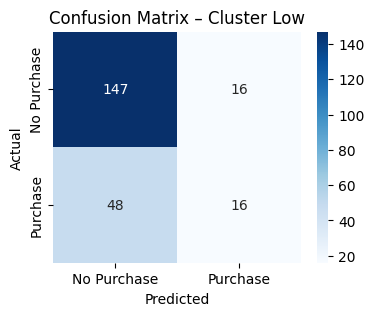

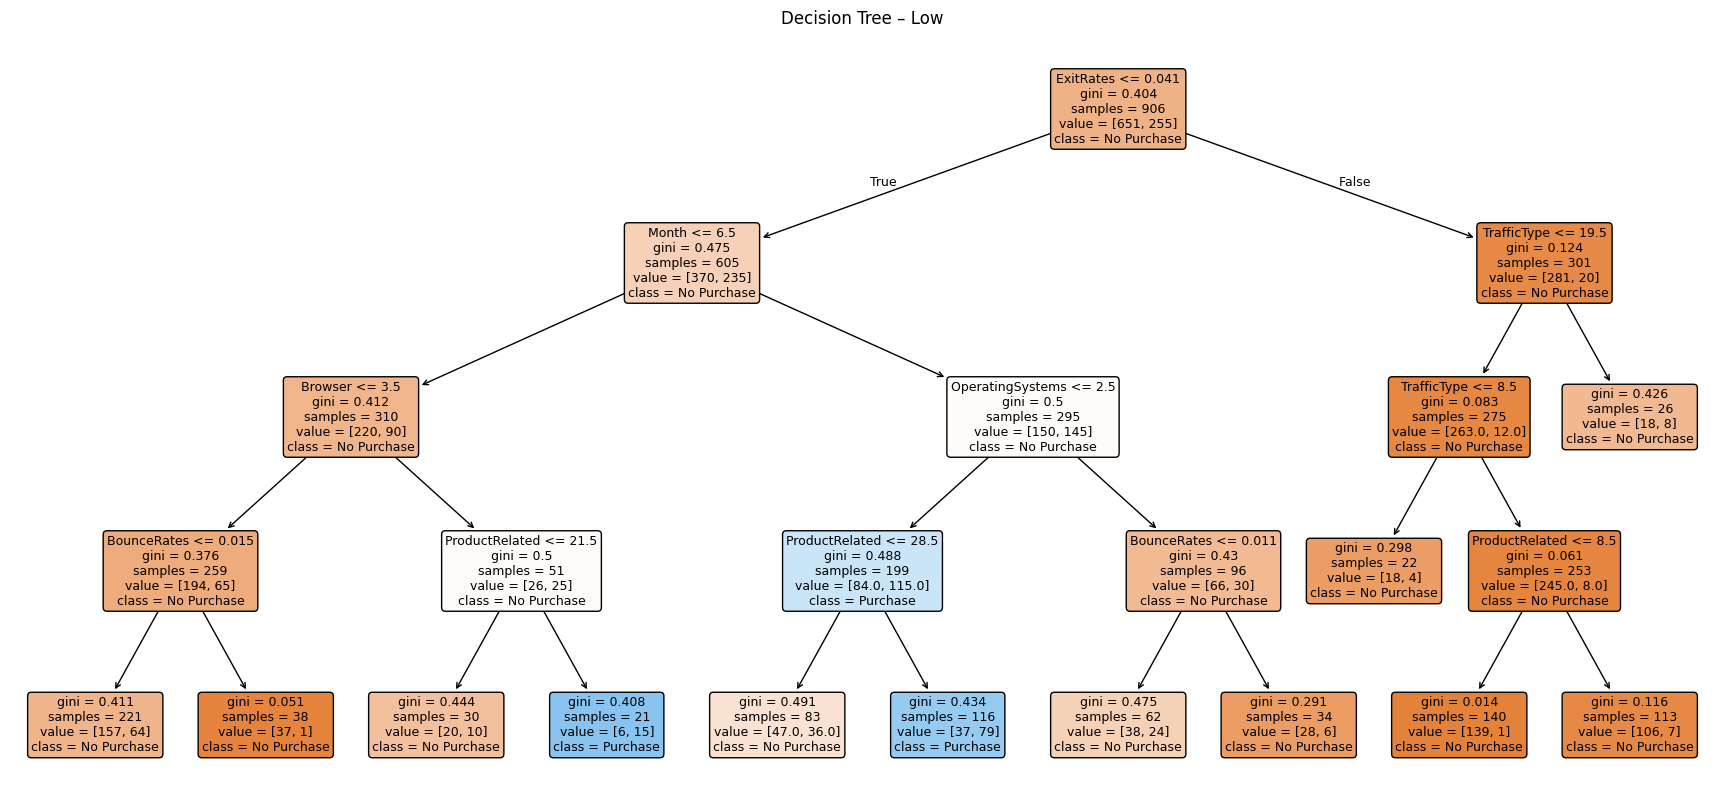

In [ ]:
df_low = df[df['cluster_name'] == 'Low']
X_low = X_all.loc[df_low.index]
y_low = df_low['Revenue']

dt_low = train_and_evaluate_decision_tree(X_low, y_low, "Low")


Phân tích cụm Low

/tmp/ipython-input-2084083463.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


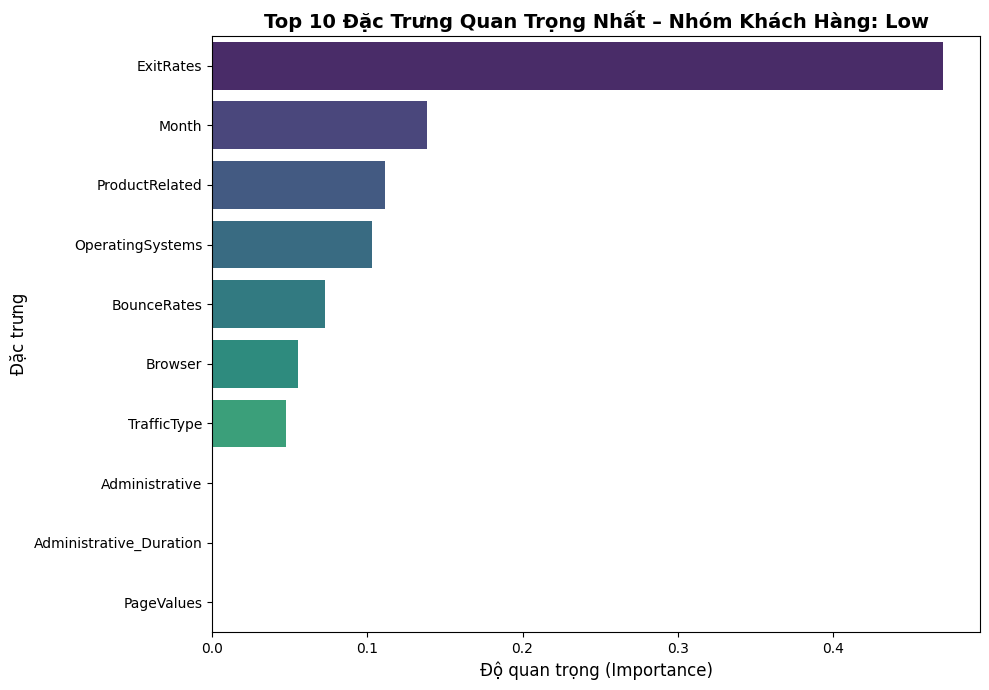

In [ ]:
#Phân tích chi tiết từng cây
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Xét cụm Low
model_to_visualize = dt_low
X_data_for_importance = X_low
cluster_name_for_plot = "Low"

# Lấy feature importance
importances = model_to_visualize.feature_importances_
features = X_data_for_importance.columns

# Tạo DataFrame để sắp xếp
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Chỉ hiển thị top 10 đặc trưng quan trọng nhất (tùy chọn)
fi_df = fi_df.head(10)

# Vẽ biểu đồ ngang (horizontal bar) đẹp hơn với seaborn
plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.xlabel('Độ quan trọng (Importance)', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.title(f'Top 10 Đặc Trưng Quan Trọng Nhất – Nhóm Khách Hàng: {cluster_name_for_plot}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###4.3.2. Cụm Medium


=== ĐÁNH GIÁ MÔ HÌNH – CỤM MEDIUM ===
Accuracy: 0.7176

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.82      0.81       190
        True       0.48      0.44      0.46        72

    accuracy                           0.72       262
   macro avg       0.64      0.63      0.64       262
weighted avg       0.71      0.72      0.71       262



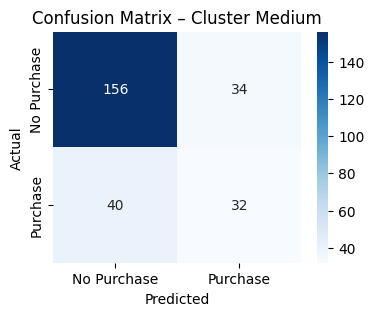

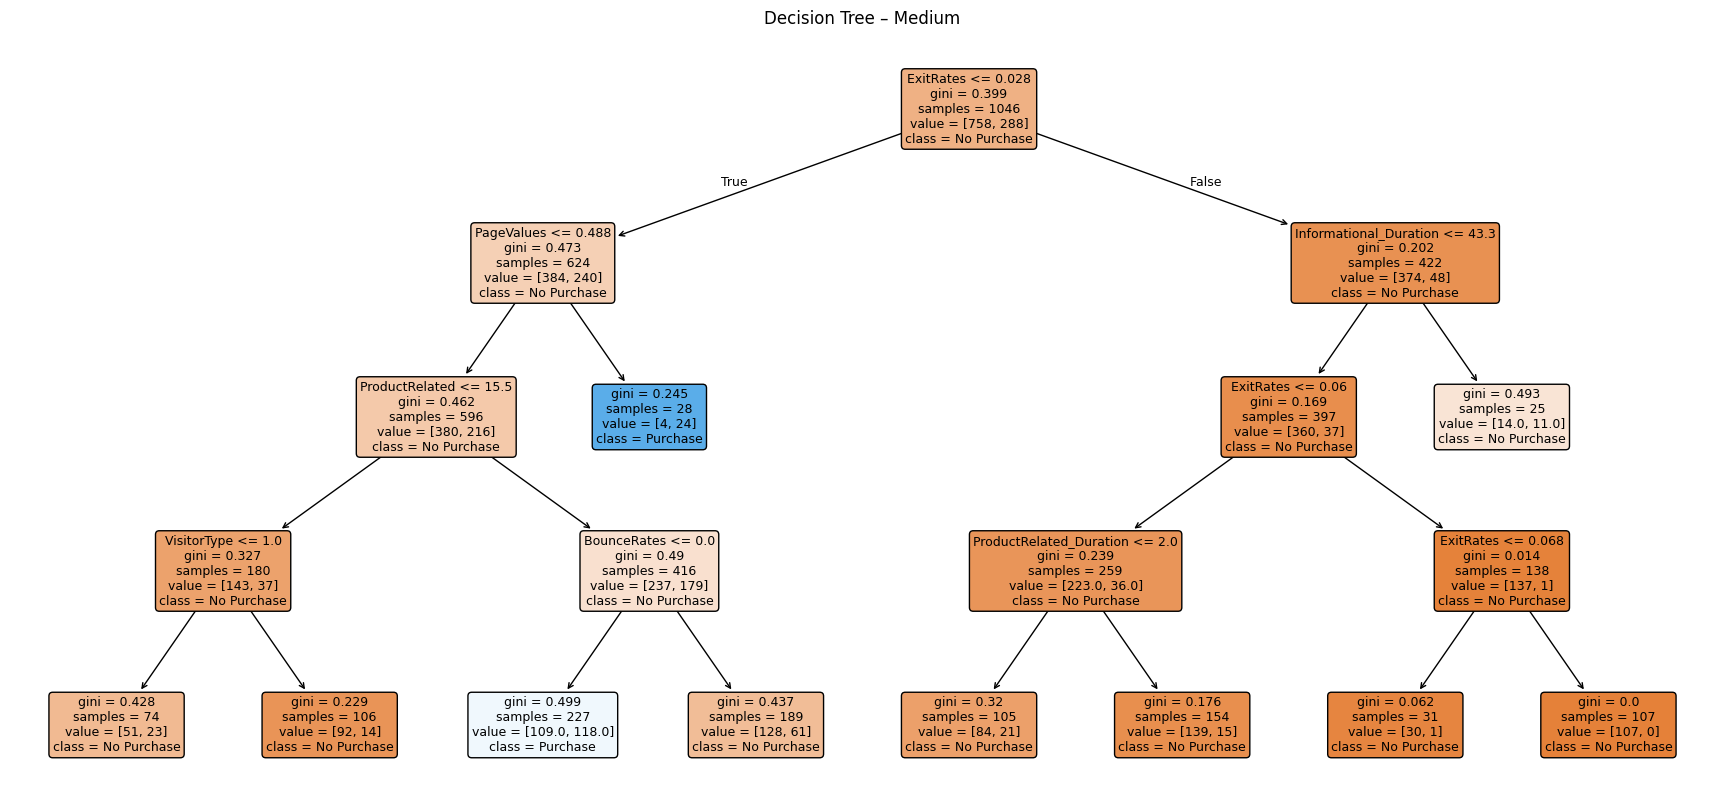

In [ ]:
df_med = df[df['cluster_name'] == 'Medium']
X_med = X_all.loc[df_med.index]
y_med = df_med['Revenue']

dt_med = train_and_evaluate_decision_tree(X_med, y_med, "Medium")


Phân tích cụm Medium

/tmp/ipython-input-2468184862.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


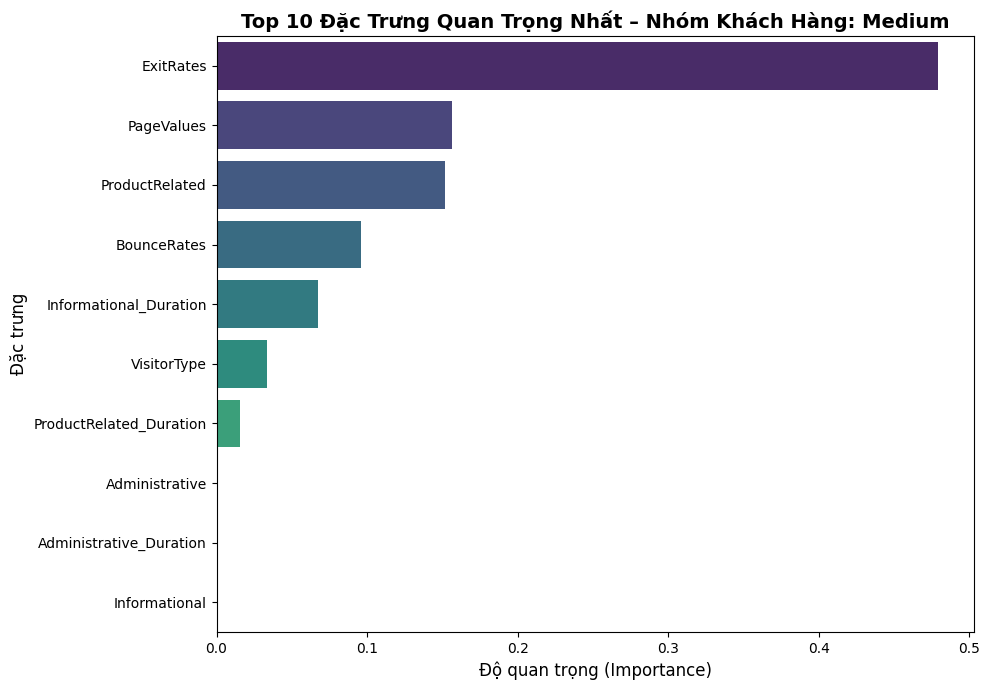

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Xét cụm Low
model_to_visualize = dt_med
X_data_for_importance = X_med
cluster_name_for_plot = "Medium"

# Lấy feature importance
importances = model_to_visualize.feature_importances_
features = X_data_for_importance.columns

# Tạo DataFrame để sắp xếp
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Chỉ hiển thị top 10 đặc trưng quan trọng nhất (tùy chọn)
fi_df = fi_df.head(10)

# Vẽ biểu đồ ngang (horizontal bar) đẹp hơn với seaborn
plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.xlabel('Độ quan trọng (Importance)', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.title(f'Top 10 Đặc Trưng Quan Trọng Nhất – Nhóm Khách Hàng: {cluster_name_for_plot}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###4.3.3. Cụm Loyal


=== ĐÁNH GIÁ MÔ HÌNH – CỤM LOYAL ===
Accuracy: 0.7573

Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.93      0.85       648
        True       0.62      0.30      0.40       246

    accuracy                           0.76       894
   macro avg       0.70      0.61      0.62       894
weighted avg       0.74      0.76      0.73       894



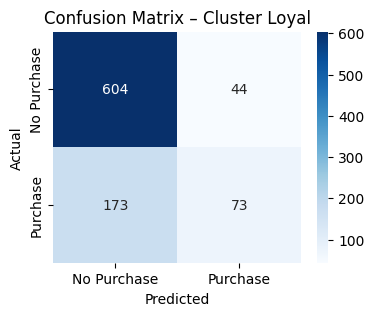

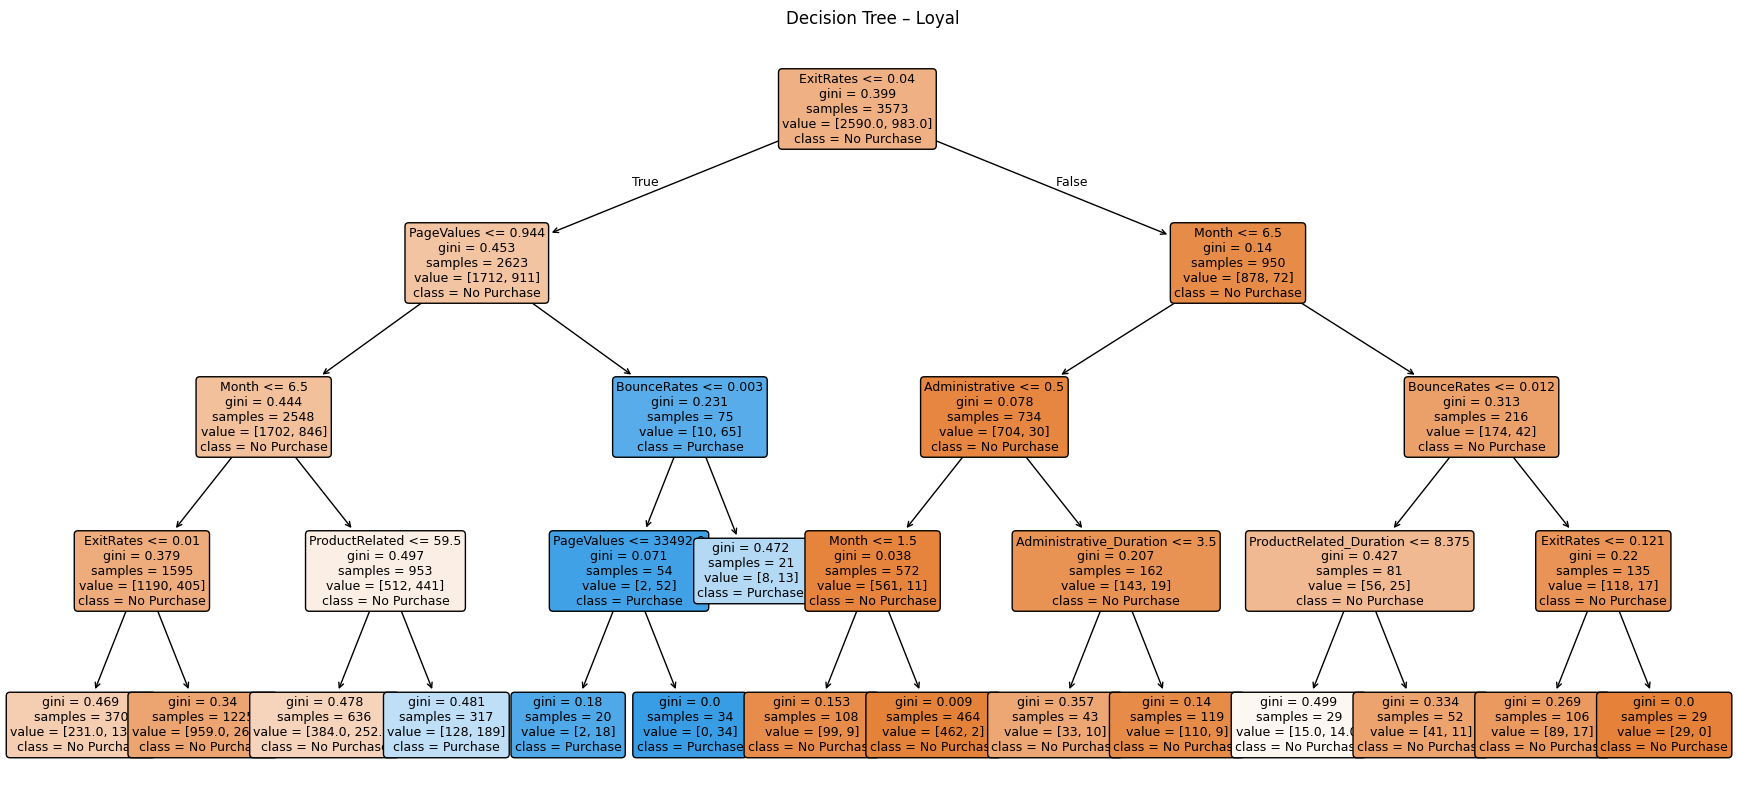

In [ ]:
df_loyal = df[df['cluster_name'] == 'Loyal']
X_loyal = X_all.loc[df_loyal.index]
y_loyal = df_loyal['Revenue']

dt_loyal = train_and_evaluate_decision_tree(X_loyal, y_loyal, "Loyal")


Phân tích cụm Loyal

/tmp/ipython-input-3050335073.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


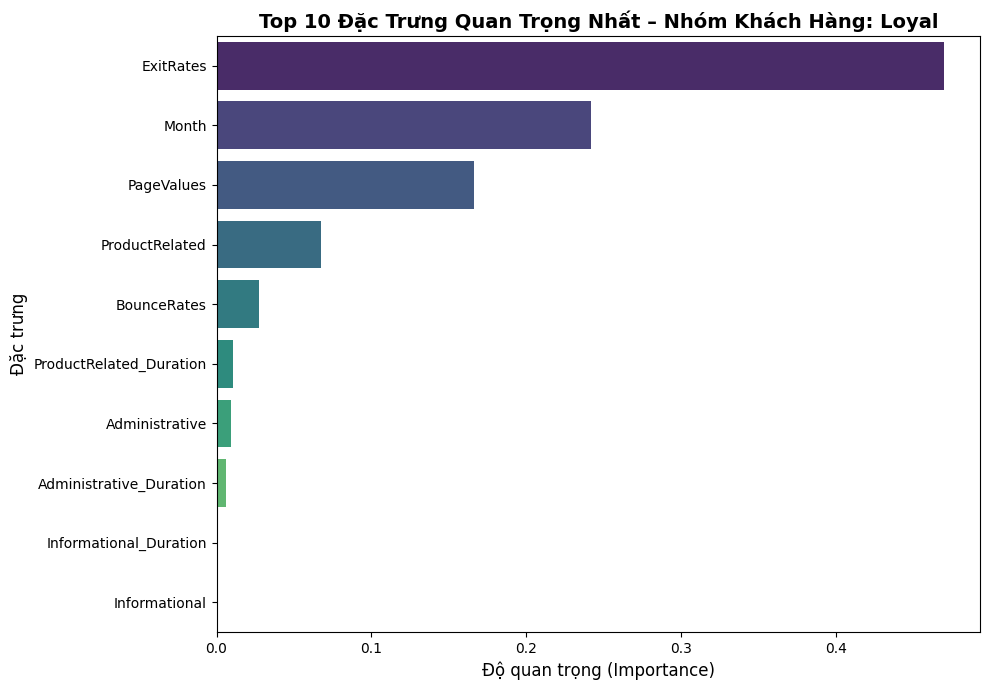

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Xét cụm Low
model_to_visualize = dt_loyal
X_data_for_importance = X_loyal
cluster_name_for_plot = "Loyal"

# Lấy feature importance
importances = model_to_visualize.feature_importances_
features = X_data_for_importance.columns

# Tạo DataFrame để sắp xếp
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Chỉ hiển thị top 10 đặc trưng quan trọng nhất (tùy chọn)
fi_df = fi_df.head(10)

# Vẽ biểu đồ ngang (horizontal bar) đẹp hơn với seaborn
plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.xlabel('Độ quan trọng (Importance)', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.title(f'Top 10 Đặc Trưng Quan Trọng Nhất – Nhóm Khách Hàng: {cluster_name_for_plot}',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##5. Kết luận


- Việc áp dụng **K-Means** với **k = 3** cụm là hợp lý, tạo ra các nhóm khách hàng có đặc trưng rõ rệt:
  - **Nhóm Loyal**: Có giá trị `PageValues` cao, thời gian truy cập lâu, tỷ lệ chuyển đổi mua hàng cao.
  - **Nhóm Medium**: Hành vi trung bình, có tiềm năng nhưng chưa chuyển đổi mạnh.
  - **Nhóm Low**: BounceRates và ExitRates cao, ít tương tác, tỷ lệ mua hàng thấp.
- Phần lớn khách hàng thuộc nhóm Loyal, phản ánh hành vi tích cực của người dùng trên nền tảng.
- Việc sử dụng **nhãn cụm làm target cho Decision Tree** giúp xây dựng được mô hình phân loại có khả năng giải thích tốt (qua cây quyết định và feature importance), hỗ trợ ra quy tắc kinh doanh thực tế.

Phương pháp kết hợp **K-Means + Decision Tree** đã chứng minh được giá trị: vừa tự động phân nhóm khách hàng, vừa tạo ra mô hình dự đoán dễ hiểu và có thể triển khai để phân loại khách hàng mới mà không cần chạy lại K-Means.